In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from stock_simulator import gbm


In [2]:
#Create a sample path of the geometric brownian motion to calculate the moving average
gbm_paths, times = gbm(n_paths=3)
gbm_paths.shape

(252, 3)

# Moving Averages Calculation

Moving average is the calculation of the mean of a time series at different points. It employs a window to choose how long to calculate the average and the starting point of the window moves forward until there are no longer enough values to fill the window.
This notebook contains functions to calculate the simple and exponential moving averages of stock. This informaition is essential to identifying trends and making future predictions. 

### Simple Moving Average

In [3]:
def simple_moving_average(prices, window_size, path=None):
    '''
    Simple Moving Average (SMA) calculation.
    prices: A numpy array of stock prices.
    window_size: The number of periods to calculate the average over.
    path: The path index for which to calculate the SMA.
    return: A numpy array of the SMA values.
    '''
    if prices.shape[1] > 1 and path is None:
        raise ValueError("Path index must be specified for multi-path data.")
    if path is not None and (path < 0 or path >= prices.shape[1]):
        raise ValueError("Path index out of bounds.")
    if path is not None:
        prices = prices[:, path]
    price_series = pd.Series(prices.flatten())
    sma = price_series.rolling(window=window_size,closed="both").mean().dropna()
    return sma

In [4]:
sma = simple_moving_average(gbm_paths, window_size=20, path = 2)

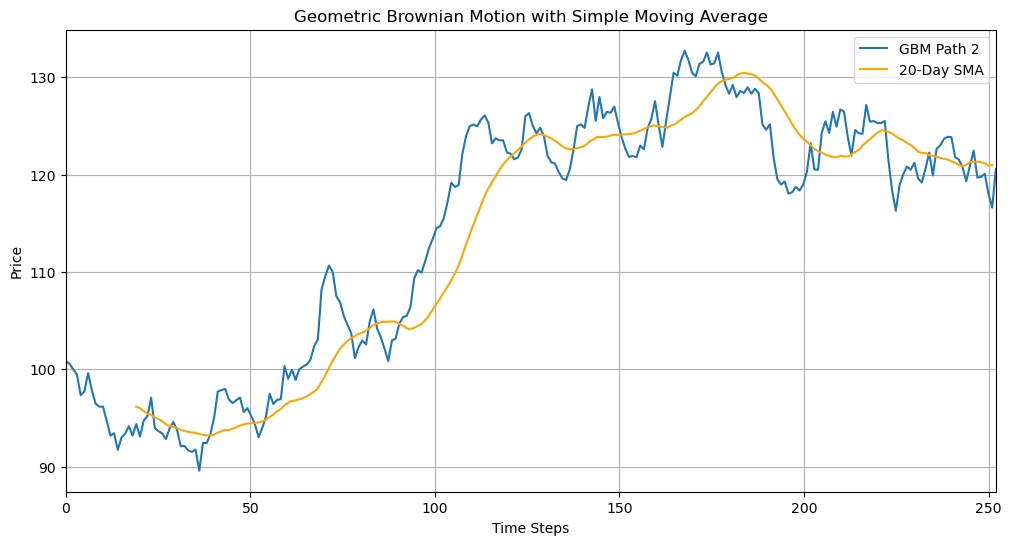

In [38]:
plt.figure(figsize=(12, 6))
plt.plot(times*252, gbm_paths[:, 2], label='GBM Path 2')
plt.plot(sma.index, sma.values, label='20-Day SMA', color='orange')
plt.xlim(0, (times*252)[-1])
plt.title('Geometric Brownian Motion with Simple Moving Average')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

### Exponential Moving Average

In [5]:
def exponential_moving_average(prices, window_size, path=None):
    '''
    Exponential Moving Average (EMA) calculation.
    prices: A numpy array of stock prices.
    window_size: The number of periods to calculate the average over.
    path: The path index for the stock prices.
    '''
    if prices.shape[1] > 1 and path is None:
        raise ValueError("Path index must be specified for multi-path data.")
    if path is not None and (path < 0 or path >= prices.shape[1]):
        raise ValueError("Path index out of bounds.")
    if path is not None:
        prices = prices[:, path]
    ema = pd.Series(prices).ewm(span=window_size, adjust=False).mean()
    return ema

In [6]:
ema = exponential_moving_average(gbm_paths, window_size=20, path=2)

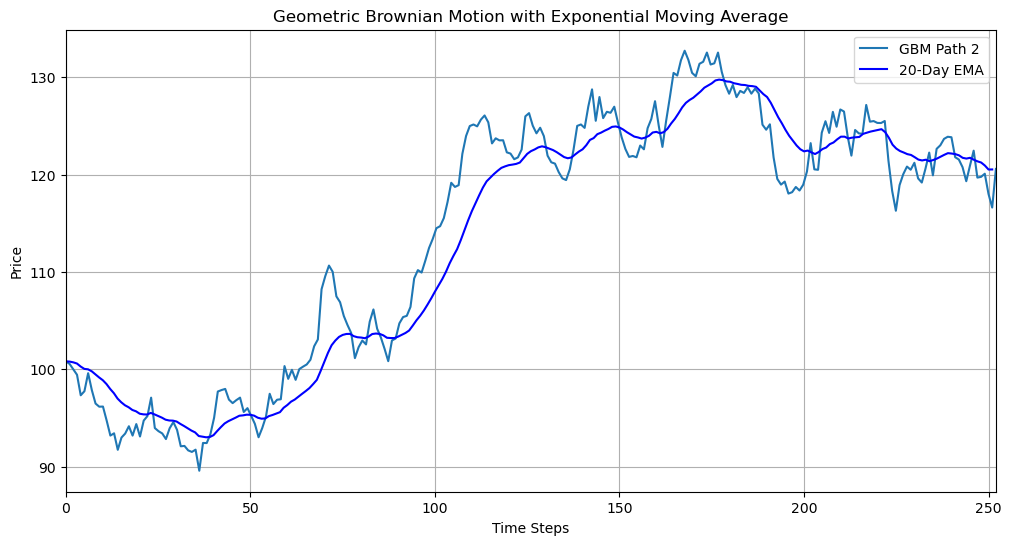

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(times*252, gbm_paths[:, 2], label='GBM Path 2')
plt.plot(ema.index, ema.values, label='20-Day EMA', color='blue')
plt.xlim(0, (times*252)[-1])
plt.title('Geometric Brownian Motion with Exponential Moving Average')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

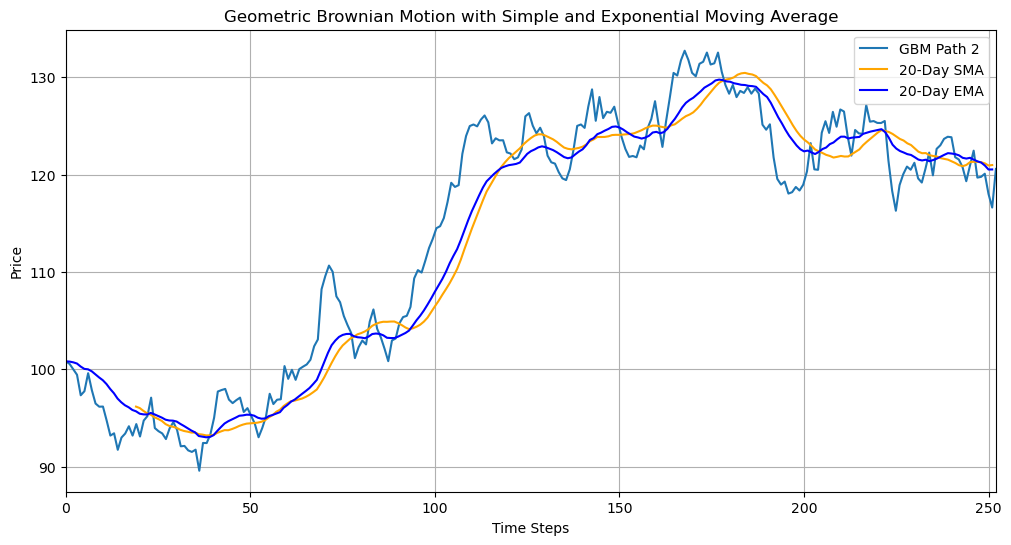

In [43]:
plt.figure(figsize=(12, 6))
plt.plot(times*252, gbm_paths[:, 2], label='GBM Path 2')
plt.plot(sma.index, sma.values, label='20-Day SMA', color='orange')
plt.plot(ema.index, ema.values, label='20-Day EMA', color='blue')
plt.xlim(0, (times*252)[-1])
plt.title('Geometric Brownian Motion with Simple and Exponential Moving Average')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()